# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from dython.nominal import associations

from heart_failure.config.config import (
    RAW_DATA_DIR,
    INTERIM_DATA_DIR,
    AGE,
    SEX,
    RESTING_BP,
    CHOLESTEROL,
    FASTING_BS,
    HEART_DISEASE,
    OLDPEAK,
    ST_SLOPE,
    EXERCISE_ANGINA,
    MAX_HR,
    RESTING_ECG
)
from heart_failure.config.features import CONJ_RULES, CAT_FEATURES
from heart_failure.dataset import split_data
from heart_failure.plots import plot_cat_value_counts, plot_cat_target_distribution, plot_corr_matrix
from heart_failure.utils import target_pct_table_by_cat, cat_pct_distr_by_group

In [20]:
df = pd.read_csv(RAW_DATA_DIR / "heart.csv")

## 1. Short information

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


The dataset contains a variety of features.

Categorical features include:
- Sex,
- ChestPainType,
- RestingECG,
- ExerciseAngina,
- FastingBS,
- ST_Slope.

Of these, the bicategorical features are:
- Sex,
- FastingBS,
- ExerciseAngina.

The remaining features, except Oldpeak (continuous), are discrete.

### 1.1 Null values

In [4]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


None

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Some features have not None, but the value 0, which theoretically shouldn't exist:

- RestingBP,
- Cholesterol

One more thing. The Cholesterol feature has a maximum value of 603. However, the internet says that such a value is theoretically possible.

In [21]:
obj_cols = df.select_dtypes(include=["object"]).columns
df[obj_cols] = df[obj_cols].astype("category")
df[FASTING_BS] = df[FASTING_BS].astype("category")

In [22]:
df[RESTING_BP] = df[RESTING_BP].replace(0, np.nan)
df[CHOLESTEROL] = df[CHOLESTEROL].replace(0, np.nan)

In [7]:
df.isna().sum().sort_values(ascending=False).head()

Cholesterol      172
RestingBP          1
Sex                0
Age                0
ChestPainType      0
dtype: int64

Given that the RestingBP feature only has one null value, this instance can be removed from the data.

For Cholesterol, the situation is slightly different. Nulls are present in more than 10 percent of the samples. Given the limited data, removing them is unlikely to be the best solution. Therefore, it's necessary to determine whether these missing values are related to other features and then decide what to do with them.

### 1.2 Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

There are no duplicates in the data.

## 2. Data distribution

### 2.1 Numeric features

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RestingBP'}>],
       [<Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'MaxHR'}>],
       [<Axes: title={'center': 'Oldpeak'}>,
        <Axes: title={'center': 'HeartDisease'}>]], dtype=object)

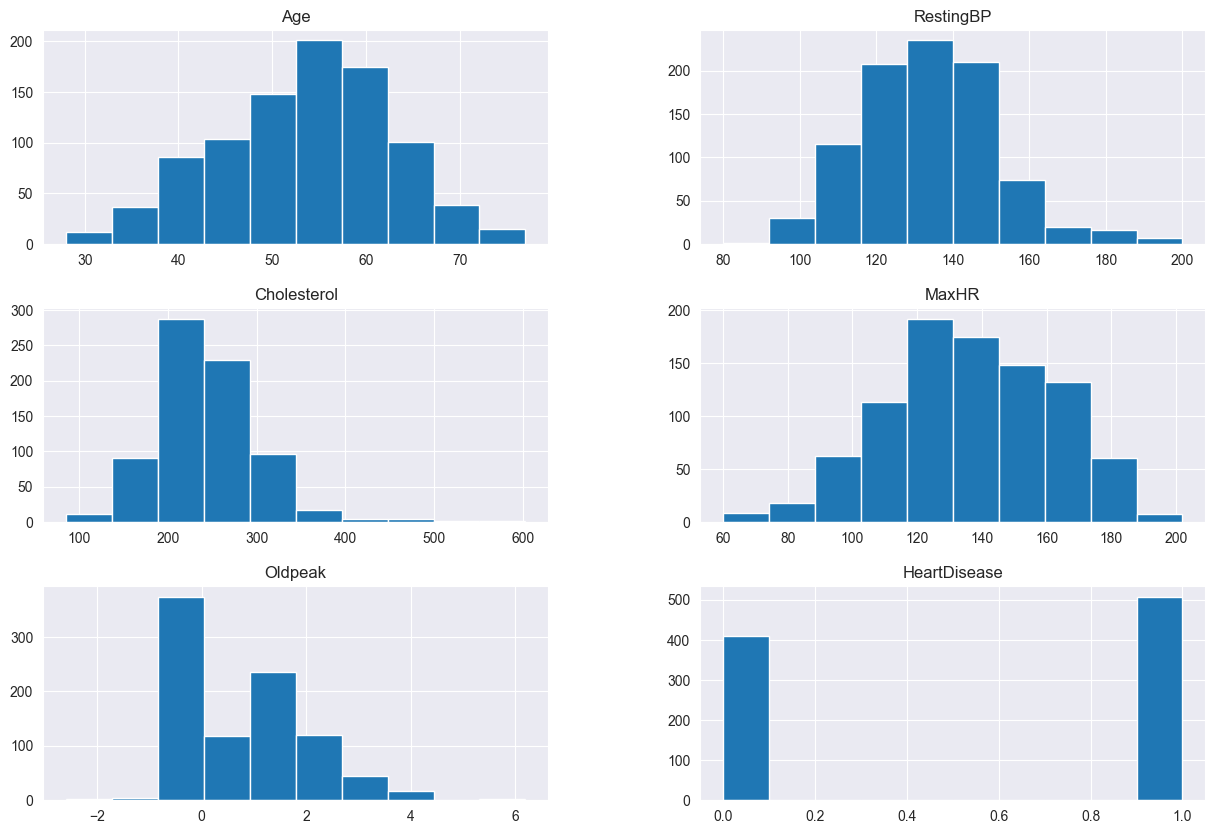

In [9]:
df.hist(figsize=(15, 10))

Some points that confused me:

- The Olpdeak feature has the most values in the range (-1; 0]. Are most of them zeros or other negative values? If it's zero, why zero? How does it differ from the other values?
- The Cholesterol feature, in addition to the extreme value of 600, also has very rare values in the range [400; 600]. Under what circumstances do these occur?

The classes are split almost equally.

### 2.2 Categorial features

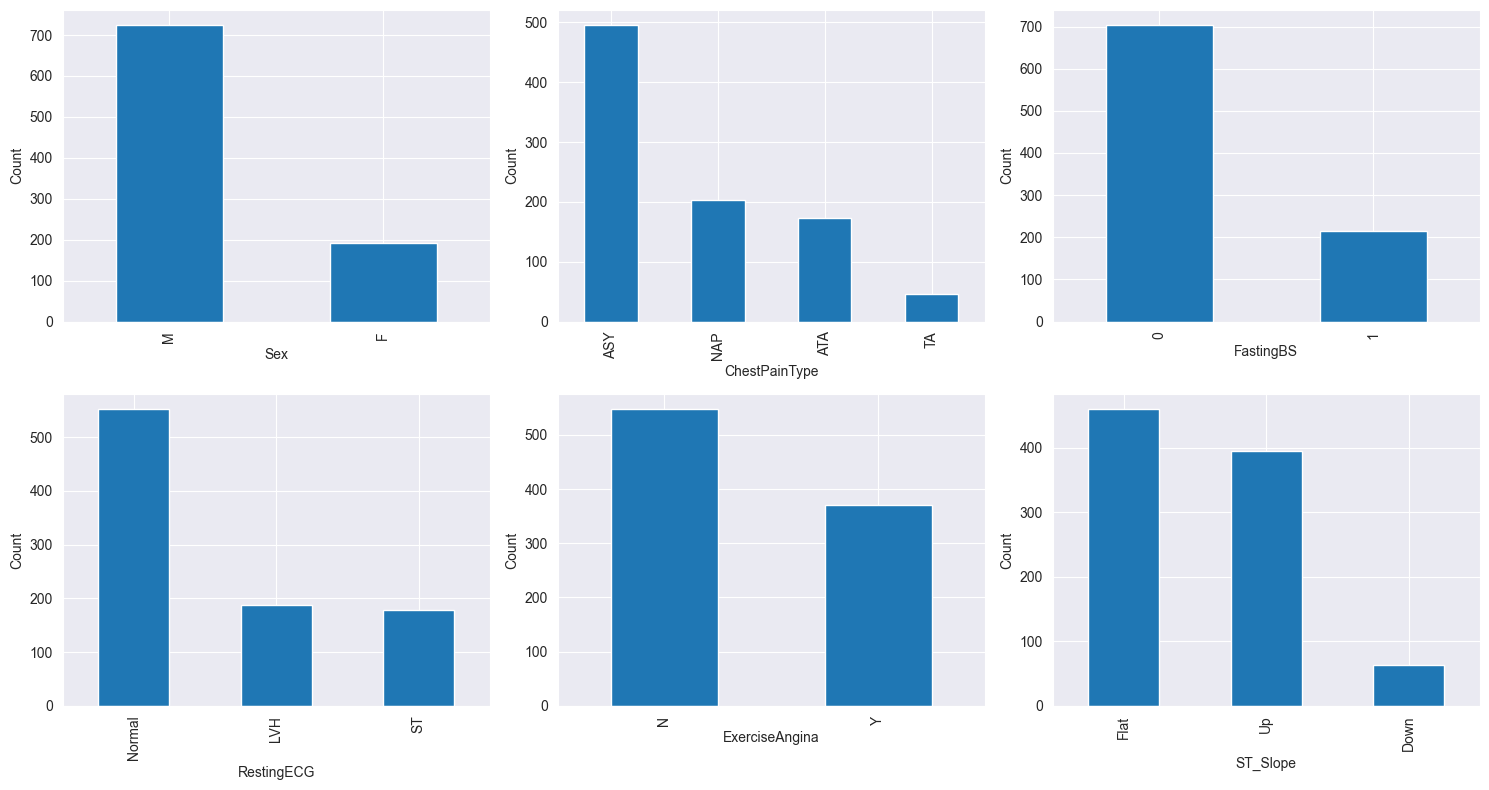

In [10]:
plot_cat_value_counts(df)

- The number of women in the data is significantly lower than that of men. Will there be enough representatives of both classes in the female population?
- Why are there relatively few cases of TA in ChestPainType and Down in ST_Slope? Judging by the internet description, these two types are strong indicators of heart disease. Will this be the case for me? Are there any other values associated with these rare cases?
- The FastingBS feature has significantly more 0s than 1s. Is the target for this feature proportionally divided?

Also, the normal range for indicators in men and women is usually different. Will the combination of features required to confirm the presence of Heart Disease differ in men and women?

I also need to determine how to implement feature encoding in the future.

### 2.3 Class distribution by features

Now I should only look at train data to avoid leakages.

In [23]:
df_train, df_val, df_test = split_data(df, stratify_func=lambda d: d[[SEX, HEART_DISEASE]])

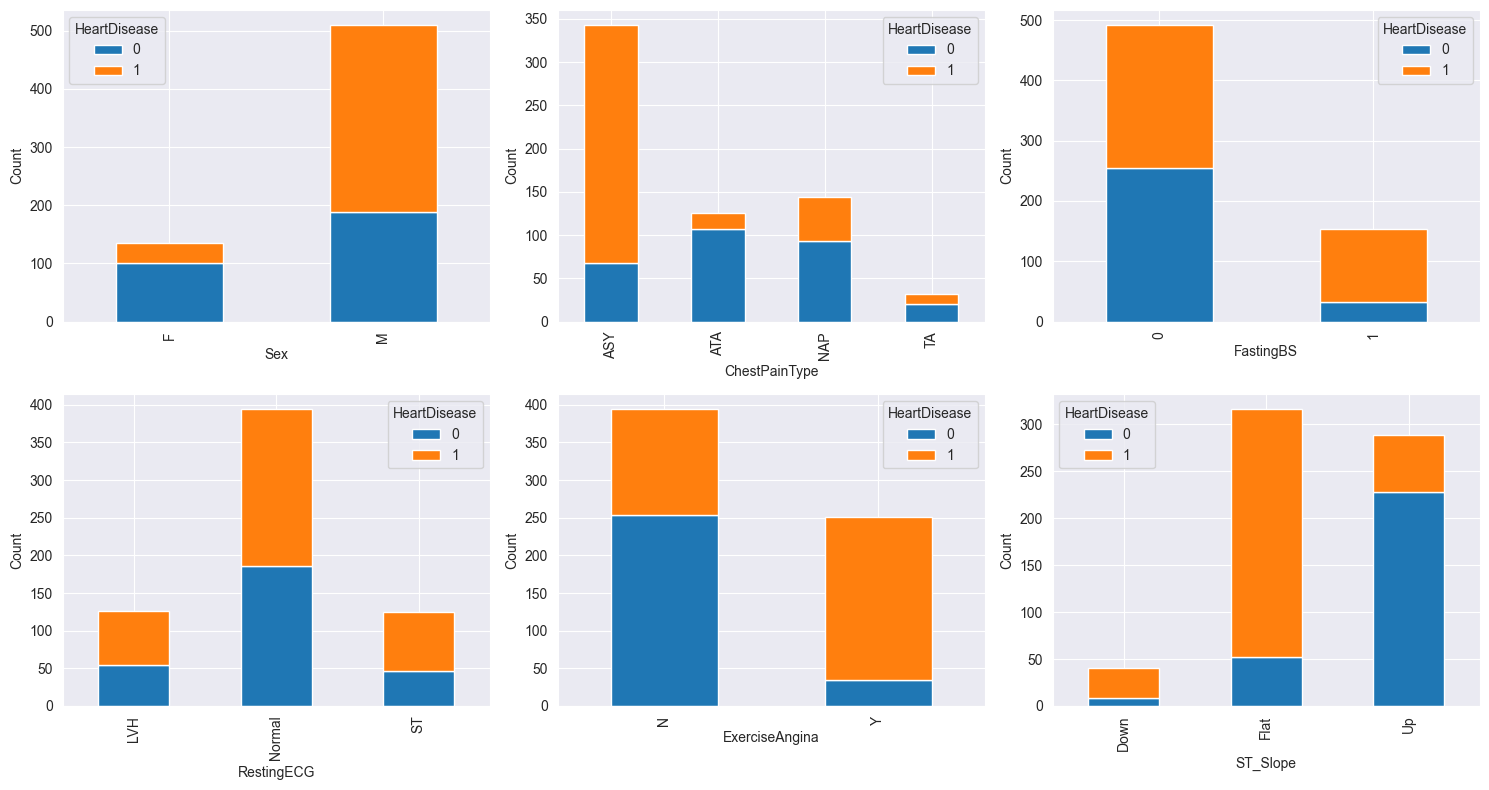

In [12]:
plot_cat_target_distribution(df_train, HEART_DISEASE)

The graphs show that certain values of some features are more or less likely to cause heart disease. For these features, the following should be examined. Does a low (high) percentage of illness mean that with this feature value, a person is less (more) likely to get disease (other features are both good and bad)? Or does a person with this feature value have good (bad) features on average, making the percentage of disease lower (higher)?

In [13]:
pct_df = target_pct_table_by_cat(df_train, HEART_DISEASE)
pct_df.loc[:, (pct_df <= 0.3).any(axis=0)]

variable     ChestPainType           ExerciseAngina FastingBS ST_Slope  \
value                  ASY       ATA              Y         1     Down   
HeartDisease                                                             
0                 0.198251  0.849206       0.139442  0.215686      0.2   
1                 0.801749  0.150794       0.860558  0.784314      0.8   

variable                               Sex  
value             Flat        Up         F  
HeartDisease                                
0             0.164557  0.788927  0.740741  
1             0.835443  0.211073  0.259259

## 3. Correlation

In [14]:
corr_df = df_train.corr(numeric_only=True)
plot_corr_matrix(corr_df)

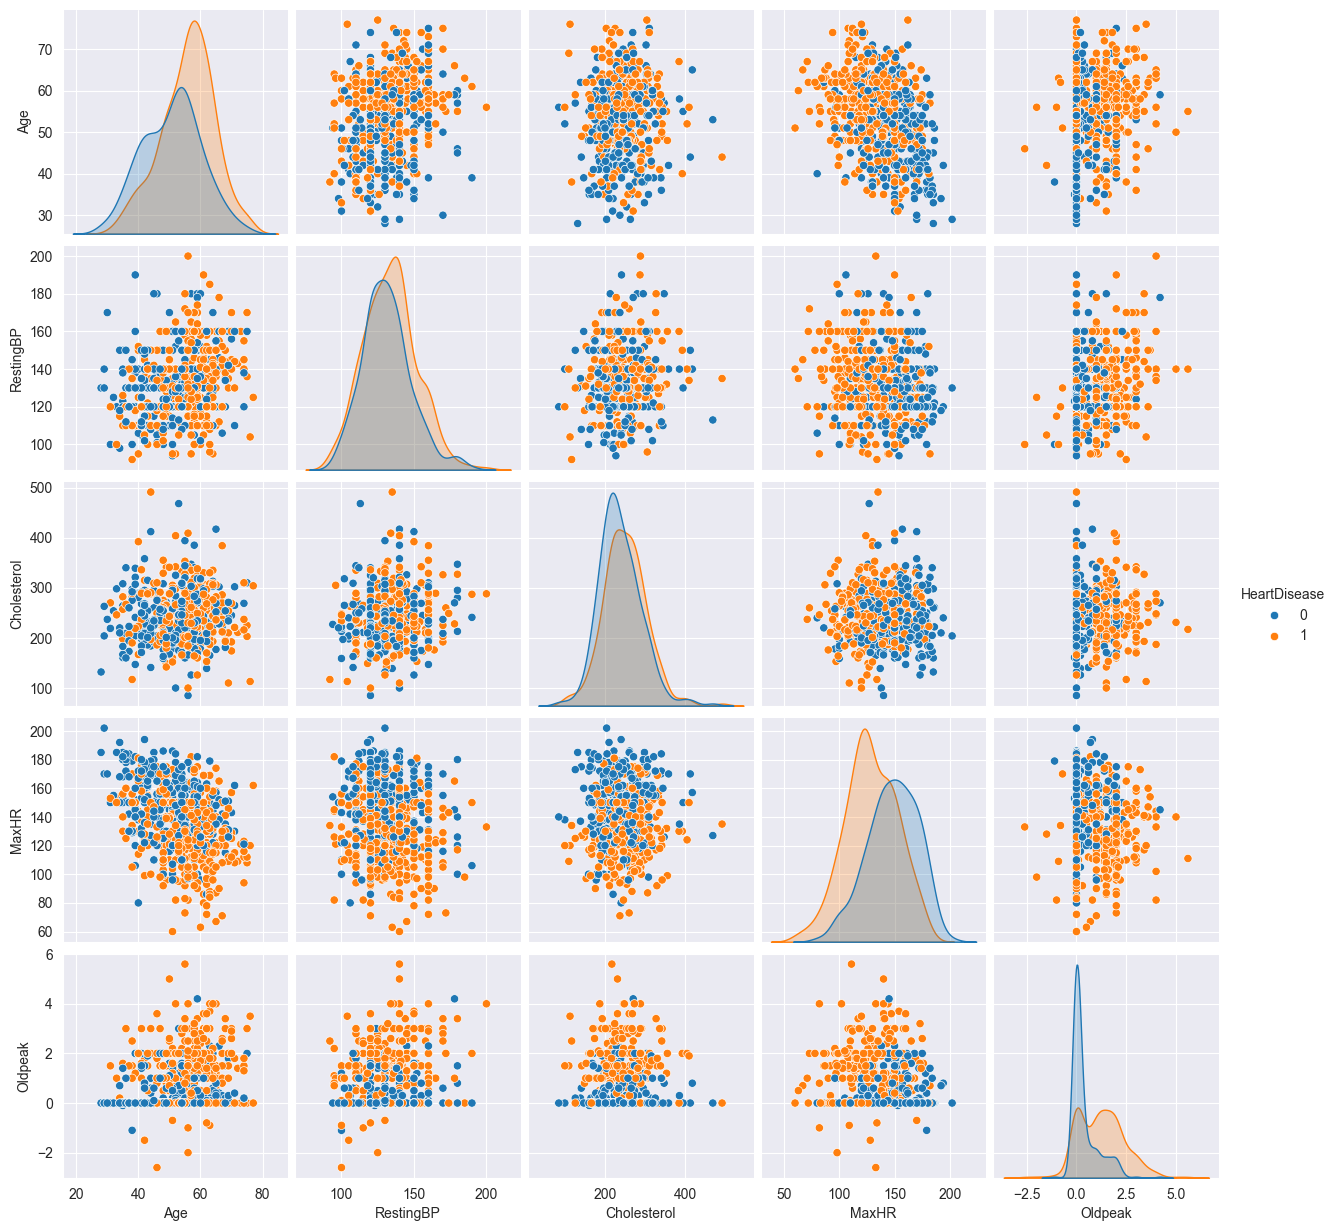

In [15]:
sns.pairplot(df_train, hue=HEART_DISEASE)
plt.show()

1. Oldpeak. Firstly, zeros, not just negative values, are indeed predominant here. Looking at the Oldpeak/Age graph, we can see that at Oldpeak=0 and Age<~60, almost no diseases are observed. For Oldpeak>0 values, the classes are mixed. This is also evident in the histogram by class: 0 appears much more frequently at target=0. Starting from a value of ~2.5, target=0 is almost never encountered.
2. MaxHR. In all graphs, higher values are more consistent with the absence of disease.
3. Cholesterol. There is no relationship with target. However, it is clear that even with large values of the feature (>400), there are cases where the disease is absent.
4. RestingBP. There is virtually no relationship with target.
5. Age. Higher age corresponds to a higher frequency of diseases.

### 3.1 Categorial feature relationships

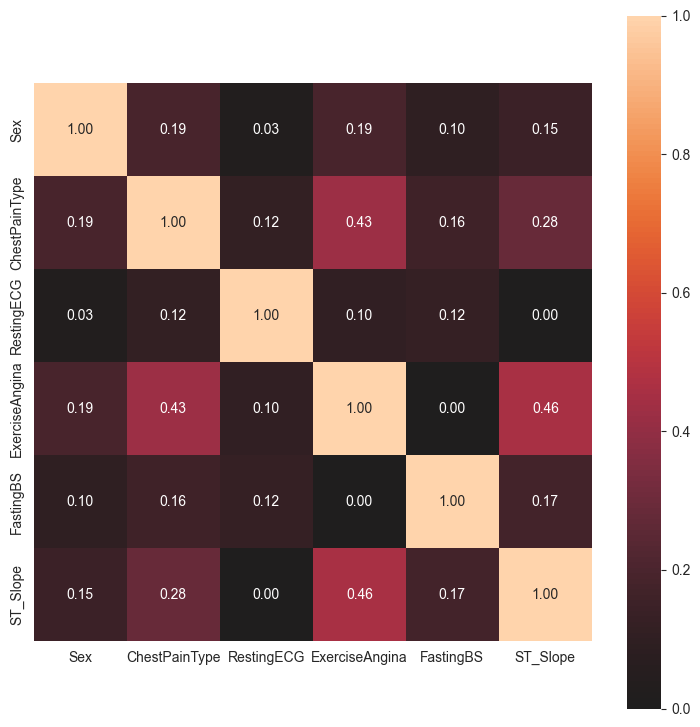

In [16]:
assoc = associations(df_train[CAT_FEATURES], nom_nom_assoc="cramer")

ExerciseAngina repeats the CPT and ST_Slope information.

## 4. Specific traits

### 4.1 Cholesterol

#### 4.1.1 Null values

In [17]:
null_mask = df_train[CHOLESTEROL].isna()
df_train.groupby(null_mask).describe()

Age                                                     \
             count       mean       std   min   25%   50%   75%   max   
Cholesterol                                                             
False        530.0  53.000000  9.445096  28.0  47.0  54.0  59.0  77.0   
True         115.0  56.191304  8.279011  34.0  52.0  57.0  62.0  74.0   

            RestingBP         ... Oldpeak      HeartDisease            \
                count   mean  ...     75%  max        count      mean   
Cholesterol                   ...                                       
False           530.0  133.1  ...     1.5  5.6        530.0  0.481132   
True            114.0  129.5  ...     1.5  3.7        115.0  0.886957   

                                                
                  std  min  25%  50%  75%  max  
Cholesterol                                     
False        0.500116  0.0  0.0  0.0  1.0  1.0  
True         0.318032  0.0  1.0  1.0  1.0  1.0  

[2 rows x 48 columns]

Key features of the group:
- The class ratio is 88:100, while in the rest of the data it's 48:100. This means this is a predominantly unhealthy group.
- All features previously noted as influencing the target have a distinctive median: Oldpeak is higher by 0.16, MaxHR is lower by 20, and Age is higher by 3.

In [18]:
cat_pct_distr_by_group(df_train, null_mask)

Sex           ChestPainType                                \
                    F         M           ASY       ATA       NAP        TA   
Cholesterol                                                                   
False        0.241509  0.758491      0.484906  0.226415  0.233962  0.054717   
True         0.060870  0.939130      0.747826  0.052174  0.173913  0.026087   

            FastingBS           RestingECG                    ExerciseAngina  \
                    0         1        LVH   Normal        ST              N   
Cholesterol                                                                    
False        0.828302  0.171698   0.224528  0.60000  0.175472       0.622642   
True         0.460870  0.539130   0.060870  0.66087  0.278261       0.556522   

                       ST_Slope                      
                    Y      Down      Flat        Up  
Cholesterol                                          
False        0.377358  0.052830  0.464151  0.483019  
True         0.443478  0.104348  0.608696  0.286957

The data is predominantly male. All features that correspond to a higher percentage of class 1 are also more common in this group.

I'm thinking of filling in the values as follows: divide the data into four groups by gender and age and fill in the median for each group.

In [24]:
bins = [0, 35, 45, 50, 55, 60, 70, 80]
AGE_BIN = "age_bin"
CHOL_MEDIAN = "chol_median"

train_medians = (
    df_train.assign(age_bin=pd.cut(df_train[AGE], bins=bins))
    .groupby([SEX, AGE_BIN], observed=True)[CHOLESTEROL]
    .median()
    .rename(CHOL_MEDIAN)
    .reset_index()
)
df[AGE_BIN] = pd.cut(df[AGE], bins=bins)
df = df.merge(train_medians, on=[SEX, AGE_BIN], how="left")
df[CHOLESTEROL] = df[CHOLESTEROL].fillna(df[CHOL_MEDIAN])

df = df.drop(columns=[AGE_BIN, CHOL_MEDIAN]).dropna()
df.to_csv(INTERIM_DATA_DIR / "heart.csv", index=False)

In [20]:
df_train, df_val, df_test = split_data(df, stratify_func=lambda d: d[[SEX, HEART_DISEASE]])

#### 4.1.2 Huge rare values

In [21]:
huge_chol_mask = df_train[CHOLESTEROL] > df_train[CHOLESTEROL].quantile(0.977)
df_train.groupby(huge_chol_mask).describe()

Age                                                     \
             count       mean       std   min   25%   50%   75%   max   
Cholesterol                                                             
False        630.0  53.615873  9.285358  28.0  48.0  54.0  60.0  76.0   
True          15.0  53.266667  8.680575  40.0  46.0  53.0  57.0  67.0   

            RestingBP              ... Oldpeak      HeartDisease            \
                count        mean  ...     75%  max        count      mean   
Cholesterol                        ...                                       
False           630.0  132.888889  ...     1.5  5.6        630.0  0.550794   
True             15.0  141.000000  ...     1.9  2.0         15.0  0.600000   

                                                
                  std  min  25%  50%  75%  max  
Cholesterol                                     
False        0.497809  0.0  0.0  1.0  1.0  1.0  
True         0.507093  0.0  0.0  1.0  1.0  1.0  

[2 rows x 48 columns]

In [22]:
cat_pct_distr_by_group(df_train, huge_chol_mask)

Sex           ChestPainType                                \
                    F         M           ASY       ATA       NAP        TA   
Cholesterol                                                                   
False        0.207937  0.792063      0.519048  0.193651  0.233333  0.053968   
True         0.333333  0.666667      0.733333  0.133333  0.133333  0.000000   

            FastingBS           RestingECG                     ExerciseAngina  \
                    0         1        LVH    Normal        ST              N   
Cholesterol                                                                     
False        0.755556  0.244444   0.195238  0.604762  0.200000       0.603175   
True         0.800000  0.200000   0.266667  0.666667  0.066667       0.600000   

                       ST_Slope                      
                    Y      Down      Flat        Up  
Cholesterol                                          
False        0.396825  0.063492  0.501587  0.434921  
True         0.400000  0.000000  0.600000  0.400000

In [23]:
df_train[huge_chol_mask]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
667,65,F,NAP,140.0,417.0,1,LVH,157,N,0.8,Up,0
250,44,M,ASY,135.0,491.0,0,Normal,135,N,0.0,Flat,1
613,58,M,ASY,140.0,385.0,1,LVH,135,N,0.3,Up,0
30,53,M,NAP,145.0,518.0,0,Normal,130,N,0.0,Flat,1
238,48,M,ASY,160.0,355.0,0,Normal,99,Y,2.0,Flat,1
872,55,M,ASY,132.0,353.0,0,Normal,132,Y,1.2,Flat,1
796,56,F,ASY,134.0,409.0,0,LVH,150,Y,1.9,Flat,1
256,55,F,ATA,130.0,394.0,0,LVH,150,N,0.0,Up,0
577,67,M,ASY,146.0,369.0,0,Normal,110,Y,1.9,Flat,1
284,42,M,ASY,140.0,358.0,0,Normal,170,N,0.0,Up,0


The features across the groups are quite similar. However, the percentage of positive cases is slightly higher with higher cholesterol levels. In all cases where the disease is present, ST_Slope = Flat.

I want to check whether the percentage of cases increases with increasing cholesterol levels overall, and not just in this group?

#### 4.1.3 Increased cholesterol levels

In [24]:
df_train.groupby(pd.qcut(df_train[CHOLESTEROL], q=10), observed=False)[HEART_DISEASE].mean()

Cholesterol
(84.999, 186.4]    0.400000
(186.4, 208.8]     0.406250
(208.8, 221.2]     0.384615
(221.2, 230.0]     0.686869
(230.0, 236.0]     0.617647
(236.0, 246.0]     0.684932
(246.0, 263.0]     0.527273
(263.0, 277.2]     0.540984
(277.2, 305.0]     0.630769
(305.0, 518.0]     0.578125
Name: HeartDisease, dtype: float64

There is no strict monotonic relationship. At high rates (after a certain threshold), the disease incidence rate is, on average, higher than at low rates.

### 4.2 Oldpeak

#### 4.2.1 Zero values

In [25]:
zero_oldpeak_mask = df_train[OLDPEAK] == 0
df_train.groupby(zero_oldpeak_mask).describe()

Age                                                    RestingBP  \
         count       mean       std   min   25%   50%   75%   max     count   
Oldpeak                                                                       
False    378.0  56.050265  8.429462  31.0  51.0  57.0  62.0  76.0     378.0   
True     267.0  50.149813  9.309226  28.0  43.0  51.0  56.0  74.0     267.0   

                     ... Oldpeak      HeartDisease                           \
               mean  ...     75%  max        count      mean       std  min   
Oldpeak              ...                                                      
False    133.952381  ...     2.0  5.6        378.0  0.701058  0.458401  0.0   
True     131.838951  ...     0.0  0.0        267.0  0.340824  0.474876  0.0   

                             
         25%  50%  75%  max  
Oldpeak                      
False    0.0  1.0  1.0  1.0  
True     0.0  0.0  1.0  1.0  

[2 rows x 48 columns]

In [26]:
cat_pct_distr_by_group(df_train, zero_oldpeak_mask)

Sex           ChestPainType                                \
                F         M           ASY       ATA       NAP        TA   
Oldpeak                                                                   
False    0.164021  0.835979      0.634921  0.095238  0.206349  0.063492   
True     0.277154  0.722846      0.367041  0.329588  0.265918  0.037453   

        FastingBS           RestingECG                     ExerciseAngina  \
                0         1        LVH    Normal        ST              N   
Oldpeak                                                                     
False    0.711640  0.288360   0.227513  0.547619  0.224868       0.444444   
True     0.820225  0.179775   0.153558  0.689139  0.157303       0.827715   

                  ST_Slope                      
                Y     Down      Flat        Up  
Oldpeak                                         
False    0.555556  0.10582  0.648148  0.246032  
True     0.172285  0.00000  0.299625  0.700375

In [27]:
up_st_slope_mask = df_train[ST_SLOPE] == "Up"
df_train[up_st_slope_mask][OLDPEAK].describe()

count    280.000000
mean       0.300357
std        0.662703
min       -1.100000
25%        0.000000
50%        0.000000
75%        0.200000
max        4.000000
Name: Oldpeak, dtype: float64

As far as I understand, the value 0 most often occurs when ST_Slope=Up. And it's the norm. There's no strict correlation between Slope=Up and Oldpeak=0. But they occur together more often than with other values.

Will the disease rate be lower if we combine Up and 0?

In [28]:
mask = up_st_slope_mask & zero_oldpeak_mask
df_train[mask][HEART_DISEASE].mean()

np.float64(0.0962566844919786)

This is the most accurate sign that the disease is not present. But we're still more interested in the circumstances under which the disease is most likely to be present.

In [29]:
df_train[mask].groupby(HEART_DISEASE)[CHOLESTEROL].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,169.0,236.307692,53.580936,85.0,202.00,226.0,267.00,468.0
1,18.0,261.555556,45.278514,177.0,237.75,260.0,288.25,335.0


In [30]:
ch_mask = mask & (df_train[CHOLESTEROL] >= df_train[CHOLESTEROL].quantile(0.75))

In [31]:
df_train[ch_mask][HEART_DISEASE].mean()

np.float64(0.16666666666666666)

Cholesterol has some influence on whether class will be 1 or not. But even under these conditions model may prefer class 0, only probability may be lower.

In [32]:
mask &= df_train[CHOLESTEROL] <= 240
tmp = df_train.groupby(mask)[HEART_DISEASE].mean().rename("disease_pct").to_frame()
tmp["non_disease_pct"] = 1 - tmp["disease_pct"]
tmp.index.name = "mask"
tmp

,disease_pct,non_disease_pct
mask,,
False,0.651206,0.348794
True,0.047170,0.952830


#### 4.2.2 Negative values

In [33]:
non_zero_train = df_train[~zero_oldpeak_mask]
neg_oldpeak_mask = non_zero_train[OLDPEAK] < 0
non_zero_train.groupby(neg_oldpeak_mask).describe()

Age                                                     RestingBP  \
         count       mean        std   min   25%   50%   75%   max     count   
Oldpeak                                                                        
False    369.0  56.173442   8.357973  31.0  51.0  57.0  62.0  76.0     369.0   
True       9.0  51.000000  10.283482  35.0  42.0  56.0  56.0  63.0       9.0   

                     ... Oldpeak      HeartDisease                           \
               mean  ...     75%  max        count      mean       std  min   
Oldpeak              ...                                                      
False    134.406504  ...     2.0  5.6        369.0  0.699187  0.459234  0.0   
True     115.333333  ...    -0.8 -0.1          9.0  0.777778  0.440959  0.0   

                             
         25%  50%  75%  max  
Oldpeak                      
False    0.0  1.0  1.0  1.0  
True     1.0  1.0  1.0  1.0  

[2 rows x 48 columns]

In [34]:
cat_pct_distr_by_group(df_train, neg_oldpeak_mask)

Sex           ChestPainType                                \
                F         M           ASY       ATA       NAP        TA   
Oldpeak                                                                   
False    0.168022  0.831978      0.636856  0.097561  0.203252  0.062331   
True     0.000000  1.000000      0.555556  0.000000  0.333333  0.111111   

        FastingBS           RestingECG                     ExerciseAngina  \
                0         1        LVH    Normal        ST              N   
Oldpeak                                                                     
False    0.720867  0.279133   0.230352  0.547425  0.222222       0.436314   
True     0.333333  0.666667   0.111111  0.555556  0.333333       0.777778   

                   ST_Slope                      
                Y      Down      Flat        Up  
Oldpeak                                          
False    0.563686  0.102981  0.655827  0.241192  
True     0.222222  0.222222  0.333333  0.444444

In [35]:
non_zero_train[neg_oldpeak_mask]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
321,63,M,ASY,100.0,246.0,1,Normal,109,N,-0.9,Flat,1
332,38,M,NAP,100.0,236.0,0,Normal,179,N,-1.1,Up,0
352,56,M,ASY,120.0,230.0,0,ST,100,Y,-1.0,Down,1
325,42,M,ASY,105.0,236.0,1,Normal,128,Y,-1.5,Down,1
334,51,M,ASY,130.0,228.0,1,Normal,170,N,-0.7,Up,1
331,56,M,ASY,115.0,230.0,1,ST,82,N,-1.0,Up,1
413,56,M,NAP,125.0,230.0,1,Normal,98,N,-2.0,Flat,1
512,35,M,NAP,123.0,161.0,0,ST,153,N,-0.1,Up,0
335,62,M,TA,120.0,246.0,1,LVH,134,N,-0.8,Flat,1


There are very few cases in the data (only 9) where oldpeak < 0. The disease has a higher frequency than usual. The distribution of the ST_Slope feature stands out - there are more Down values and fewer Flat values. It's possible that this is simply an error in the data and the value should be positive, since the percentage and distribution are similar to other cases (non-zero). But that's not certain.

I'll check later how often the model is wrong in such cases.

### 4.3 Presence of heart disease

Let's look at the disease rate under different conditions. What will it be under different combinations of conditions? And what will be the disease rate for other cases not included in this mask?

In [36]:
conditions = {name: rule(df_train) for name, rule in CONJ_RULES.items()}
result = []

for names in combinations(conditions.keys(), 2):
    mask = np.logical_and.reduce([conditions[n] for n in names])

    result.append({
        "conditions": " & ".join(names),
        "count": mask.sum(),
        "disease_pct": df_train.loc[mask, HEART_DISEASE].mean(),
        "non_disease_pct": 1 - df_train.loc[mask, HEART_DISEASE].mean(),
        "unaccounted_diseases": (df_train.loc[~mask, HEART_DISEASE] == 1).sum(),
    })

result = pd.DataFrame(result)
count_mask = result["count"] >= 45
result[count_mask].sort_values(["disease_pct", "count"], ascending=False).head(10)

,conditions,count,disease_pct,non_disease_pct,unaccounted_diseases
43,FastingBS eq 1 & ST_Slope eq Flat,97,0.958763,0.041237,263
36,ChestPain eq ASY & FastingBS eq 1,99,0.949495,0.050505,262
5,Oldpeak ge 2 & ExerciseAngina eq Y,82,0.939024,0.060976,279
39,ExerciseAngina eq Y & FastingBS eq 1,68,0.926471,0.073529,293
35,ChestPain eq ASY & ExerciseAngina eq Y,202,0.920792,0.079208,170
4,Oldpeak ge 2 & ChestPain eq ASY,88,0.920455,0.079545,275
38,ChestPain eq ASY & ST_Slope eq Flat,220,0.918182,0.081818,154
8,Oldpeak ge 2 & ST_Slope eq Flat,85,0.917647,0.082353,278
41,ExerciseAngina eq Y & ST_Slope eq Flat,192,0.911458,0.088542,181
20,MaxHR le 150 & ExerciseAngina eq Y,231,0.896104,0.103896,149


ChestPain has the highest percentage of occurrences in pairs, but this doesn't mean they're all different pairs. All conditions can be present in the same cases. The remaining characteristics, except age, appear at roughly the same rate.

However, each pair individually doesn't cover the entire spectrum of diseases: outside the mask, ~50% belong to class 1.

For the baseline, we could experiment with combining conditions (taking OR of the best ones or adding combinations of three) to achieve a better result. For now, the point is that, based on individual criteria, we can say that a disease is very likely to appear here.

### 4.4 Gender differences

#### 4.4.1 Feature difference by disease

In [37]:
df_train.groupby([SEX, HEART_DISEASE], observed=False).describe()

Age                                                      \
                  count       mean       std   min    25%   50%   75%   max   
Sex HeartDisease                                                              
F   0             101.0  51.386139  9.414850  30.0  45.00  52.0  57.0  74.0   
    1              35.0  55.800000  8.453332  33.0  50.50  57.0  62.0  73.0   
M   0             188.0  50.537234  9.460512  28.0  42.75  52.0  57.0  75.0   
    1             321.0  55.866044  8.511250  31.0  51.00  57.0  62.0  76.0   

                 RestingBP              ...  MaxHR        Oldpeak            \
                     count        mean  ...    75%    max   count      mean   
Sex HeartDisease                        ...                                   
F   0                101.0  129.356436  ...  164.0  192.0   101.0  0.385149   
    1                 35.0  141.628571  ...  153.0  170.0    35.0  1.048571   
M   0                188.0  132.382979  ...  165.0  202.0   188.0  0.373936   
    1                321.0  133.722741  ...  143.0  195.0   321.0  1.279751   

                                                     
                       std  min  25%  50%  75%  max  
Sex HeartDisease                                     
F   0             0.602227  0.0  0.0  0.0  0.6  2.0  
    1             1.119446  0.0  0.0  1.0  1.5  4.0  
M   0             0.707342 -1.1  0.0  0.0  0.4  4.2  
    1             1.156555 -2.0  0.0  1.3  2.0  5.6  

[4 rows x 40 columns]

In [38]:
cat_pct_distr_by_group(df_train, [df_train[SEX], df_train[HEART_DISEASE]])

Sex      ChestPainType                                \
                    F    M           ASY       ATA       NAP        TA   
Sex HeartDisease                                                         
F   0             1.0  0.0      0.207921  0.405941  0.326733  0.059406   
    1             1.0  0.0      0.771429  0.057143  0.142857  0.028571   
M   0             0.0  1.0      0.255319  0.351064  0.319149  0.074468   
    1             0.0  1.0      0.753894  0.046729  0.158879  0.040498   

                 FastingBS           RestingECG                      \
                         0         1        LVH    Normal        ST   
Sex HeartDisease                                                      
F   0             0.910891  0.089109   0.217822  0.623762  0.158416   
    1             0.685714  0.314286   0.228571  0.657143  0.114286   
M   0             0.872340  0.127660   0.175532  0.659574  0.164894   
    1             0.647975  0.352025   0.199377  0.563863  0.236760   

                 ExerciseAngina            ST_Slope                      
                              N         Y      Down      Flat        Up  
Sex HeartDisease                                                         
F   0                  0.910891  0.089109  0.000000  0.237624  0.762376  
    1                  0.457143  0.542857  0.085714  0.800000  0.114286  
M   0                  0.856383  0.143617  0.042553  0.148936  0.808511  
    1                  0.373832  0.626168  0.090343  0.763240  0.146417

While the mean and median RestingBP levels in men do not differ when grouped by class, this is not the case for women. With disease, RestingBP is, on average, higher.

There is a difference between cholesterol levels by class in both men and women. However, in women, this difference is much greater. Since the average age is 50, women have higher levels on average than men. This explains the similarity in mean cholesterol levels for groups M_1 and F_0.

The mean MaxHR differs more significantly between M_0 and M_1 than between F_0 and F_1. However, the values for M_0 and F_0 are approximately the same.

RestingECG=ST is as common in women with disease as without it. However, there is a difference in men.

As a result, the combination of conditions for the disease likely differs between men and women.

- Does RestingBP have a greater impact on the risk of disease in women?
- Does Cholesterol have a greater impact on the risk of disease in women?
- Does a lower MaxHR affect the risk of disease in women?
- Does a lower RestingECG affect the risk of disease in women?

I'm also still interested why such a low percentage of women get disease.

#### 4.4.2 Age groups

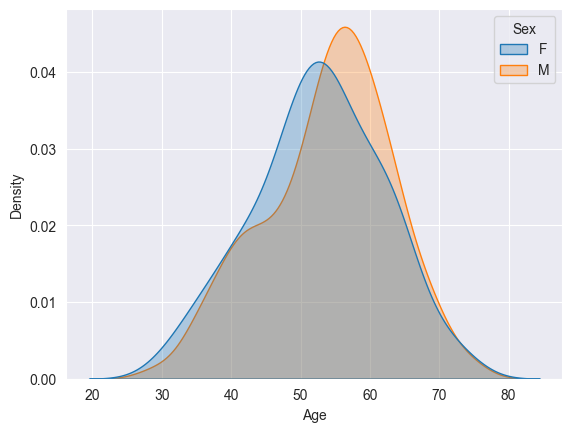

In [39]:
sns.kdeplot(df_train, x=AGE, hue=SEX, fill=True, common_norm=False, alpha=0.3)
plt.show()

The average age of women and men who are healthy is around 50. At this age, women experience menopause, after which cholesterol levels rise, increasing the risk of disease. Visually, women have more values before 50, while men have more values after 50. This may explain the difference in percentages.

In [62]:
df_age_balanced = df_train.copy()
age_bin = pd.cut(df_age_balanced[AGE], bins=range(0, 81, 10))
grouped = df_age_balanced.groupby(age_bin, observed=True)
df_age_balanced = grouped.apply(
    lambda x: x.groupby(SEX, observed=True).sample(
        n=x[SEX].value_counts().min(), random_state=42
    )
)

In [63]:
df_age_balanced.groupby(SEX, observed=True)[HEART_DISEASE].mean()

Sex
F    0.257353
M    0.639706
Name: HeartDisease, dtype: float64

Even with the same age distribution, the percentage of the disease still differs between the genders.

#### 4.4.3 Influence of different features

In [ ]:
x_vars = [RESTING_BP, CHOLESTEROL, MAX_HR]
tmp = df_train.melt([SEX, HEART_DISEASE], x_vars)

g = sns.FacetGrid(
    tmp,
    row=SEX,
    col="variable",
    hue=HEART_DISEASE,
    sharex=False,
    sharey=False,
    height=4,
    aspect=1.3,
)

g.map(sns.kdeplot, "value", fill=True)
g.add_legend()
plt.show()

All cases are indeed different for men and women. RestingBP and Cholesterol are more important in women, while MaxHR is less important (but still has an impact).

### 4.5 RestingECG

Does the feature have any impact on the target? Perhaps different disease conditions are responsible for different values?

In [41]:
df_train.groupby([RESTING_ECG, HEART_DISEASE], observed=False).describe()

Age                                                \
                         count       mean        std   min   25%   50%   75%   
RestingECG HeartDisease                                                        
LVH        0              55.0  54.109091  10.210149  28.0  49.5  54.0  59.0   
           1              72.0  58.458333   7.014949  35.0  56.0  59.0  62.0   
Normal     0             187.0  49.893048   9.044651  29.0  42.5  50.0  56.0   
           1             204.0  53.882353   9.033374  31.0  48.0  54.0  61.0   
ST         0              47.0  50.744681   9.379599  30.0  45.0  53.0  56.5   
           1              80.0  58.562500   6.828540  40.0  55.0  58.0  63.0   

                              RestingBP              ...  MaxHR         \
                          max     count        mean  ...    75%    max   
RestingECG HeartDisease                              ...                 
LVH        0             74.0      55.0  130.854545  ...  168.5  202.0   
           1             76.0      72.0  138.750000  ...  150.0  195.0   
Normal     0             75.0     187.0  130.791444  ...  166.0  194.0   
           1             74.0     204.0  131.558824  ...  145.0  182.0   
ST         0             68.0      47.0  134.000000  ...  154.0  185.0   
           1             74.0      80.0  138.175000  ...  140.0  163.0   

                        Oldpeak                                               \
                          count      mean       std  min    25%   50%    75%   
RestingECG HeartDisease                                                        
LVH        0               55.0  0.589091  0.832816  0.0  0.000  0.30  0.900   
           1               72.0  1.436111  1.223054 -0.8  0.075  1.40  2.425   
Normal     0              187.0  0.313369  0.603202 -1.1  0.000  0.00  0.300   
           1              204.0  1.161765  1.114309 -2.0  0.000  1.10  2.000   
ST         0               47.0  0.387234  0.683220 -0.1  0.000  0.00  0.400   
           1               80.0  1.338750  1.176618 -1.0  0.450  1.35  2.000   

                              
                         max  
RestingECG HeartDisease       
LVH        0             4.2  
           1             4.0  
Normal     0             2.0  
           1             5.6  
ST         0             3.0  
           1             5.0  

[6 rows x 40 columns]

The risk of disease is higher for the ST value, and the risk is lowest for the Normal value. The average age for the Normal value is lower than for the others, and we remember that the risk of the disease increases with age.

Looking at the average MaxHR, the value for ST for both classes is, on average, lower than for LVH, even though the age groups are roughly the same. This means that a relatively low MaxHR value does not always indicate the presence of the disease.

### 4.6 Other features with low (high) percentage of disease

#### 4.6.1 FastingBS

In [42]:
df_train.groupby([FASTING_BS, HEART_DISEASE], observed=False).describe()

Age                                                 \
                        count       mean       std   min    25%   50%    75%   
FastingBS HeartDisease                                                         
0         0             256.0  50.152344  9.354261  28.0  42.75  51.0  56.00   
          1             232.0  54.974138  8.684924  31.0  50.00  56.0  61.00   
1         0              33.0  56.121212  8.465952  39.0  51.00  56.0  61.00   
          1             124.0  57.516129  7.894100  34.0  53.00  58.0  62.25   

                             RestingBP              ...  MaxHR        Oldpeak  \
                         max     count        mean  ...    75%    max   count   
FastingBS HeartDisease                              ...                         
0         0             74.0     256.0  130.703125  ...  165.0  202.0   256.0   
          1             76.0     232.0  133.995690  ...  145.0  195.0   232.0   
1         0             75.0      33.0  136.151515  ...  162.0  194.0    33.0   
          1             74.0     124.0  135.443548  ...  145.0  176.0   124.0   

                                                                       
                            mean       std  min  25%  50%    75%  max  
FastingBS HeartDisease                                                 
0         0             0.363281  0.668609 -1.1  0.0  0.0  0.500  4.2  
          1             1.391810  1.190210 -1.0  0.0  1.4  2.000  5.6  
1         0             0.490909  0.692984  0.0  0.0  0.1  1.000  2.3  
          1             1.004839  1.039845 -2.0  0.0  1.0  1.725  4.0  

[4 rows x 40 columns]

In [43]:
cat_pct_distr_by_group(df_train, [df_train[FASTING_BS], df_train[HEART_DISEASE]])

Sex           ChestPainType                      \
                               F         M           ASY       ATA       NAP   
FastingBS HeartDisease                                                         
0         0             0.359375  0.640625      0.250000  0.386719  0.304688   
          1             0.103448  0.896552      0.754310  0.051724  0.159483   
1         0             0.272727  0.727273      0.151515  0.242424  0.454545   
          1             0.088710  0.911290      0.758065  0.040323  0.153226   

                                 FastingBS      RestingECG            \
                              TA         0    1        LVH    Normal   
FastingBS HeartDisease                                                 
0         0             0.058594       1.0  0.0   0.175781  0.656250   
          1             0.034483       1.0  0.0   0.219828  0.612069   
1         0             0.151515       0.0  1.0   0.303030  0.575758   
          1             0.048387       0.0  1.0   0.169355  0.500000   

                                 ExerciseAngina            ST_Slope            \
                              ST              N         Y      Down      Flat   
FastingBS HeartDisease                                                          
0         0             0.167969       0.878906  0.121094  0.015625  0.187500   
          1             0.168103       0.323276  0.676724  0.081897  0.775862   
1         0             0.121212       0.848485  0.151515  0.121212  0.121212   
          1             0.330645       0.491935  0.508065  0.104839  0.750000   

                                  
                              Up  
FastingBS HeartDisease            
0         0             0.796875  
          1             0.142241  
1         0             0.757576  
          1             0.145161

At FastingBS=1, the average of all features except MaxHR and Oldpeak are approximately equal. This contrasts with FastingBS=0, where healthy individuals have a lower average age and lower cholesterol.

A FastingBS=1 is not a primary indicator of a higher risk of heart failure. It simply reflects a higher incidence of older individuals, who are more likely to develop heart failure.

#### 4.6.2 Exersice Angina

In [44]:
df_train.groupby([EXERCISE_ANGINA, HEART_DISEASE], observed=False).describe()

Age                                          \
                             count       mean       std   min    25%   50%   
ExerciseAngina HeartDisease                                                  
N              0             253.0  50.233202  9.372630  28.0  43.00  51.0   
               1             136.0  55.073529  9.160004  34.0  49.00  56.0   
Y              0              36.0  55.055556  8.908886  40.0  47.75  56.5   
               1             220.0  56.345455  8.037511  31.0  52.00  57.0   

                                         RestingBP              ...  MaxHR  \
                               75%   max     count        mean  ...    75%   
ExerciseAngina HeartDisease                                     ...          
N              0             56.00  74.0     253.0  130.873518  ...  168.0   
               1             61.00  76.0     136.0  130.786765  ...  155.0   
Y              0             60.25  75.0      36.0  134.500000  ...  152.5   
               1             62.00  74.0     220.0  136.795455  ...  140.0   

                                   Oldpeak                                     \
                               max   count      mean       std  min  25%  50%   
ExerciseAngina HeartDisease                                                     
N              0             202.0   253.0  0.314625  0.624169 -1.1  0.0  0.0   
               1             195.0   136.0  0.805147  1.104423 -2.0  0.0  0.3   
Y              0             186.0    36.0  0.822222  0.820143  0.0  0.0  0.9   
               1             182.0   220.0  1.536364  1.095297 -1.5  1.0  1.5   

                                       
                             75%  max  
ExerciseAngina HeartDisease            
N              0             0.3  4.2  
               1             1.5  4.4  
Y              0             1.5  3.0  
               1             2.0  5.6  

[4 rows x 40 columns]

The age at Y is on average higher, which is why some indicators differ on average.

In [45]:
df_train[df_train[AGE].between(54, 56)].groupby([EXERCISE_ANGINA], observed=False).describe()

Age                                                     \
               count       mean       std   min   25%   50%   75%   max   
ExerciseAngina                                                            
N               59.0  54.745763  0.821966  54.0  54.0  55.0  55.0  56.0   
Y               38.0  55.210526  0.810669  54.0  55.0  55.0  56.0  56.0   

               RestingBP              ... Oldpeak      HeartDisease            \
                   count        mean  ...     75%  max        count      mean   
ExerciseAngina                        ...                                       
N                   59.0  130.423729  ...    0.45  2.0         59.0  0.254237   
Y                   38.0  137.605263  ...    2.50  5.6         38.0  0.973684   

                                                   
                     std  min  25%  50%  75%  max  
ExerciseAngina                                     
N               0.439169  0.0  0.0  0.0  0.5  1.0  
Y               0.162221  0.0  1.0  1.0  1.0  1.0  

[2 rows x 48 columns]

If we take a specific age group, the disease rate remains higher at age Y. So, it's not a matter of age. But at the same time, oldpeak is higher in group Y, so the feature itself may not introduce new information.

# 5 Possible features

- Age binning. 51 and 55 should be in different bins.
- Separate continuum features by age and gender norms. Cholesterol, MaxHR.
- Binary categories are simply set to 1/0 (Sex, FastingBS, ExerciseAngina).
- Use target encoding for categories (RestingECG, ChestPainType, ST_Slope).
- Split oldpeak into bins (quantiles), and use target encoding for categories (what percentage of disease does oldpeak have in this bin for this category) (ST_Slope, ExerciseAngina, ChestPaintType).
- Same for MaxHR RestingECG.
- Age/MaxHR

## Conclusion

- Given that the RestingBP feature only has one null value, this instance can be removed from the data.
- The classes are split almost equally across data.
- For the Cholesterol feature, null values primarily refer to the unhealthy group, predominantly male. The median for the gender and age groups can be used for filling.
- The disease percentage for the Slope=Up and Oldpeak=0 groups is quite small.
- The combination of features required to confirm the presence of Heart disease differs in men and women.

Features:
1. Oldpeak. Zeros, not just negative values, are indeed predominant here. 0 appears much more frequently at target=0. Starting from a value of ~2.5, target=0 is almost never encountered.
2. MaxHR. Higher values are more consistent with the absence of disease.
3. Cholesterol. Even with large values of the feature (>400), there are cases where the disease is absent. At high rates (after a certain threshold), the percentage of disease is on average higher than at low rates.
4. RestingBP has some impact on the target. MaxHR for ST for both classes is, on average, lower than for LVH, even though the age groups are roughly the same. Relatively low MaxHR value does not always indicate the presence of the disease.
5. Age. Higher age corresponds to a higher frequency of diseases.
6. FastingBS=1 is not a primary indicator of a higher risk of heart failure. It simply reflects a higher incidence of older individuals, who are more likely to develop heart failure.